## Problem Statement

A bike-sharing system is a service in which bikes are made available for shared use to individuals on a short term basis for a price or free. Many bike share systems allow people to borrow a bike from a "dock" which is usually computer-controlled wherein the user enters the payment information, and the system unlocks it. This bike can then be returned to another dock belonging to the same system.

A US bike-sharing provider BoomBikes has recently suffered considerable dips in their revenues due to the ongoing Corona pandemic. The company is finding it very difficult to sustain in the current market scenario. So, it has decided to come up with a mindful business plan to be able to accelerate its revenue as soon as the ongoing lockdown comes to an end, and the economy restores to a healthy state. 

In such an attempt, BoomBikes aspires to understand the demand for shared bikes among the people after this ongoing quarantine situation ends across the nation due to Covid-19. They have planned this to prepare themselves to cater to the people's needs once the situation gets better all around and stand out from other service providers and make huge profits.

They have contracted a consulting company to understand the factors on which the demand for these shared bikes depends. Specifically, they want to understand the factors affecting the demand for these shared bikes in the American market. The company wants to know:
Which variables are significant in predicting the demand for shared bikes.
How well those variables describe the bike demands
Based on various meteorological surveys and people's styles, the service provider firm has gathered a large dataset on daily bike demands across the American market based on some factors. 

### Business Goal:

You are required to model the demand for shared bikes with the available independent variables. It will be used by the management to understand how exactly the demands vary with different features. They can accordingly manipulate the business strategy to meet the demand levels and meet the customer's expectations. Further, the model will be a good way for management to understand the demand dynamics of a new market. 

In [5]:
# Supressing the Warnings

import warnings
warnings.filterwarnings('ignore')

In [6]:
# Importing the packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [7]:
# Reading the given CSV file, and view some sample records

bike = pd.read_csv("/Users/divyadevendrasingh/Downloads/day.csv")
bike.head(10)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600
5,6,06-01-2018,1,0,1,0,6,0,1,8.378268,11.66045,51.8261,6.000868,88,1518,1606
6,7,07-01-2018,1,0,1,0,0,0,2,8.057402,10.44195,49.8696,11.304642,148,1362,1510
7,8,08-01-2018,1,0,1,0,1,1,2,6.765000,8.11270,53.5833,17.875868,68,891,959
8,9,09-01-2018,1,0,1,0,2,1,1,5.671653,5.80875,43.4167,24.250650,54,768,822
9,10,10-01-2018,1,0,1,0,3,1,1,6.184153,7.54440,48.2917,14.958889,41,1280,1321


In [8]:
# Checking the descriptive information
bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [9]:
bike.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.995890,0.690411,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.000339,0.462641,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [10]:
#Shape of data frame
bike.shape

(730, 16)

### Data Quality Check

In [12]:
# percentage of missing values in each column
round(100*(bike.isnull().sum()/len(bike)), 2).sort_values()

instant       0.0
dteday        0.0
season        0.0
yr            0.0
mnth          0.0
holiday       0.0
weekday       0.0
workingday    0.0
weathersit    0.0
temp          0.0
atemp         0.0
hum           0.0
windspeed     0.0
casual        0.0
registered    0.0
cnt           0.0
dtype: float64

There are no missing values in the columns

In [14]:
# row-wise null count percentage
round(100*(bike.isnull().sum(axis = 1)/len(bike)),2).sort_values()

0      0.0
481    0.0
482    0.0
483    0.0
484    0.0
      ... 
246    0.0
247    0.0
248    0.0
250    0.0
729    0.0
Length: 730, dtype: float64

There are no null values in the rows

In [16]:
bike_dup = bike.drop_duplicates()     # Dropping duplicates if present
bike_dup.shape

(730, 16)

No duplicates present in the dataset

### Data Cleaning

In [19]:
bike_dummy = bike.loc[:, bike.columns[1:16]]

In [20]:
for cols in bike_dummy:
    print(bike_dummy[cols].value_counts(ascending=False),'\n')

dteday
01-01-2018    1
25-04-2019    1
27-04-2019    1
28-04-2019    1
29-04-2019    1
             ..
03-09-2018    1
04-09-2018    1
05-09-2018    1
06-09-2018    1
31-12-2019    1
Name: count, Length: 730, dtype: int64 

season
3    188
2    184
1    180
4    178
Name: count, dtype: int64 

yr
0    365
1    365
Name: count, dtype: int64 

mnth
1     62
3     62
5     62
7     62
8     62
10    62
12    62
4     60
6     60
9     60
11    60
2     56
Name: count, dtype: int64 

holiday
0    709
1     21
Name: count, dtype: int64 

weekday
1    105
2    105
3    104
4    104
5    104
6    104
0    104
Name: count, dtype: int64 

workingday
1    504
0    226
Name: count, dtype: int64 

weathersit
1    463
2    246
3     21
Name: count, dtype: int64 

temp
26.035000    5
10.899153    5
27.880000    4
28.563347    4
23.130847    4
            ..
27.435847    1
26.376653    1
28.989419    1
28.700000    1
8.849153     1
Name: count, Length: 498, dtype: int64 

atemp
32.73440    4
18.78105

There are no unknown values in dataset

In [22]:
bike.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [23]:
#Removing unwanted columns

new_bike = bike[['season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'cnt']]

In [24]:
new_bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      730 non-null    int64  
 1   yr          730 non-null    int64  
 2   mnth        730 non-null    int64  
 3   holiday     730 non-null    int64  
 4   weekday     730 non-null    int64  
 5   workingday  730 non-null    int64  
 6   weathersit  730 non-null    int64  
 7   temp        730 non-null    float64
 8   atemp       730 non-null    float64
 9   hum         730 non-null    float64
 10  windspeed   730 non-null    float64
 11  cnt         730 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 68.6 KB


#### Creating Dummy Variables

In [26]:
# Converting few columns to 'category' data type from int or float

new_bike[['season', 'weathersit', 'mnth', 'weekday']] = new_bike[['season', 'weathersit', 'mnth', 'weekday']].astype('category')

In [27]:
# Checking for the updated data type
new_bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   season      730 non-null    category
 1   yr          730 non-null    int64   
 2   mnth        730 non-null    category
 3   holiday     730 non-null    int64   
 4   weekday     730 non-null    category
 5   workingday  730 non-null    int64   
 6   weathersit  730 non-null    category
 7   temp        730 non-null    float64 
 8   atemp       730 non-null    float64 
 9   hum         730 non-null    float64 
 10  windspeed   730 non-null    float64 
 11  cnt         730 non-null    int64   
dtypes: category(4), float64(4), int64(4)
memory usage: 49.7 KB


In [28]:
# Converting categorical variables into dummy/indicator variables

new_bike = pd.get_dummies(new_bike, drop_first = True)   #drop_first- drops first level of each categorical col to prevent multicollinearity
new_bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 30 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   yr            730 non-null    int64  
 1   holiday       730 non-null    int64  
 2   workingday    730 non-null    int64  
 3   temp          730 non-null    float64
 4   atemp         730 non-null    float64
 5   hum           730 non-null    float64
 6   windspeed     730 non-null    float64
 7   cnt           730 non-null    int64  
 8   season_2      730 non-null    bool   
 9   season_3      730 non-null    bool   
 10  season_4      730 non-null    bool   
 11  mnth_2        730 non-null    bool   
 12  mnth_3        730 non-null    bool   
 13  mnth_4        730 non-null    bool   
 14  mnth_5        730 non-null    bool   
 15  mnth_6        730 non-null    bool   
 16  mnth_7        730 non-null    bool   
 17  mnth_8        730 non-null    bool   
 18  mnth_9        730 non-null    

In [29]:
# Converting only columns with bool type to uint8
bool_columns = new_bike.select_dtypes(include=['bool']).columns
new_bike[bool_columns] = new_bike[bool_columns].astype('uint8')

In [30]:
# Checking the DataFrame info again
new_bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 30 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   yr            730 non-null    int64  
 1   holiday       730 non-null    int64  
 2   workingday    730 non-null    int64  
 3   temp          730 non-null    float64
 4   atemp         730 non-null    float64
 5   hum           730 non-null    float64
 6   windspeed     730 non-null    float64
 7   cnt           730 non-null    int64  
 8   season_2      730 non-null    uint8  
 9   season_3      730 non-null    uint8  
 10  season_4      730 non-null    uint8  
 11  mnth_2        730 non-null    uint8  
 12  mnth_3        730 non-null    uint8  
 13  mnth_4        730 non-null    uint8  
 14  mnth_5        730 non-null    uint8  
 15  mnth_6        730 non-null    uint8  
 16  mnth_7        730 non-null    uint8  
 17  mnth_8        730 non-null    uint8  
 18  mnth_9        730 non-null    

In [31]:
new_bike.shape

(730, 30)

### Data Split

In [33]:
np.random.seed(0)       # Set random seed for making the results reproducible
train_data, test_data = train_test_split(new_bike, train_size = 0.70, test_size = 0.30, random_state = 300)

In [34]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 510 entries, 337 to 481
Data columns (total 30 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   yr            510 non-null    int64  
 1   holiday       510 non-null    int64  
 2   workingday    510 non-null    int64  
 3   temp          510 non-null    float64
 4   atemp         510 non-null    float64
 5   hum           510 non-null    float64
 6   windspeed     510 non-null    float64
 7   cnt           510 non-null    int64  
 8   season_2      510 non-null    uint8  
 9   season_3      510 non-null    uint8  
 10  season_4      510 non-null    uint8  
 11  mnth_2        510 non-null    uint8  
 12  mnth_3        510 non-null    uint8  
 13  mnth_4        510 non-null    uint8  
 14  mnth_5        510 non-null    uint8  
 15  mnth_6        510 non-null    uint8  
 16  mnth_7        510 non-null    uint8  
 17  mnth_8        510 non-null    uint8  
 18  mnth_9        510 non-null    uin

In [35]:
train_data.shape

(510, 30)

In [36]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 219 entries, 146 to 293
Data columns (total 30 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   yr            219 non-null    int64  
 1   holiday       219 non-null    int64  
 2   workingday    219 non-null    int64  
 3   temp          219 non-null    float64
 4   atemp         219 non-null    float64
 5   hum           219 non-null    float64
 6   windspeed     219 non-null    float64
 7   cnt           219 non-null    int64  
 8   season_2      219 non-null    uint8  
 9   season_3      219 non-null    uint8  
 10  season_4      219 non-null    uint8  
 11  mnth_2        219 non-null    uint8  
 12  mnth_3        219 non-null    uint8  
 13  mnth_4        219 non-null    uint8  
 14  mnth_5        219 non-null    uint8  
 15  mnth_6        219 non-null    uint8  
 16  mnth_7        219 non-null    uint8  
 17  mnth_8        219 non-null    uint8  
 18  mnth_9        219 non-null    uin

In [37]:
test_data.shape

(219, 30)

### Exploratory Data Analysis

Performing EDA on train_dataset

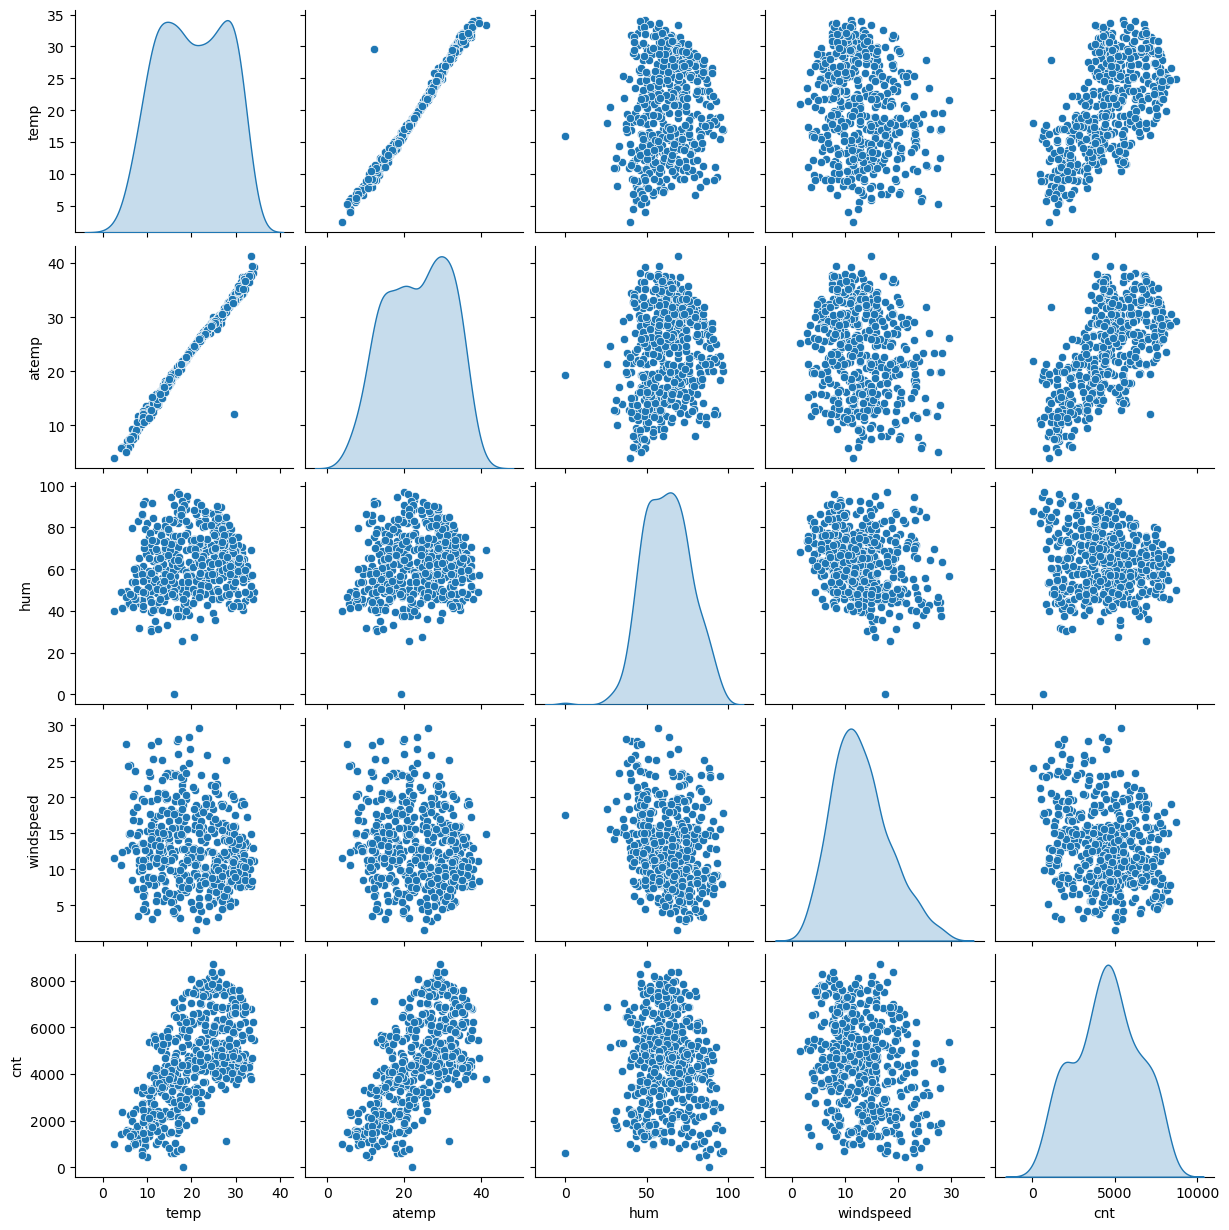

In [40]:
# Visualizing only numeric variables:

num_cols_in_bike = train_data[[ 'temp', 'atemp', 'hum', 'windspeed', 'cnt']]
sns.pairplot(num_cols_in_bike, diag_kind = 'kde')
plt.show()

By seeing numeric visualization, there is a 'Linear Relation' between 'temp','atemp' and 'cnt'

In [205]:
correlation_matrix = num_cols_in_bike.corr()
target_correlation = correlation_matrix['cnt'].drop('cnt')

# Identifying the variable with highest correlation with 'cnt'
highest_corr_variable = target_correlation.idxmax()
highest_corr_value = target_correlation.max()
highest_corr_variable, highest_corr_value

('atemp', 0.6290768198852457)

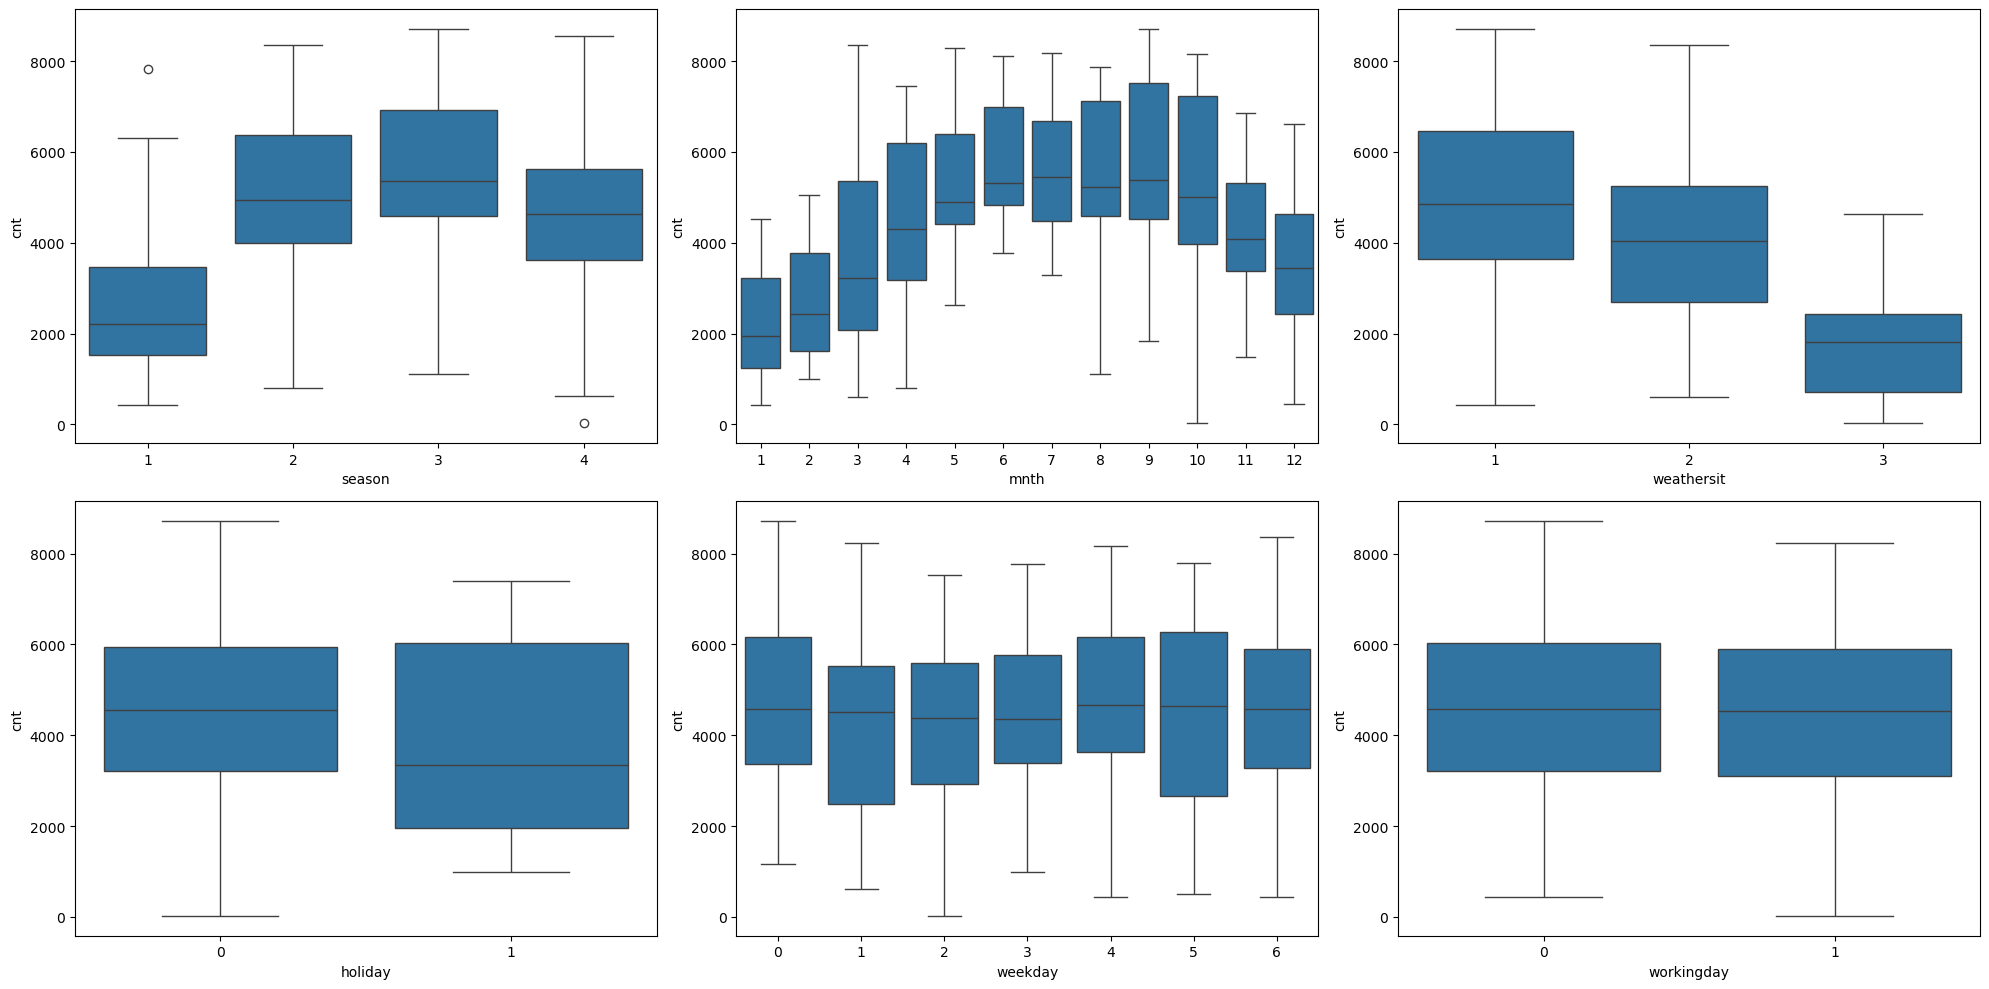

In [43]:
# Visualizing only categorical variables:

fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 3)
categoric_vars = ['season', 'mnth', 'weathersit', 'holiday', 'weekday', 'workingday']  # Lists of categories

for i, category in enumerate(categoric_vars):
    sns.boxplot(data = bike, x = category, y = 'cnt', ax = axes[i//3, i%3])

plt.tight_layout()  # Adjusts subplot parameters to give some padding and prevent overlap
plt.show()

1. Season: Season 3 recorded the highest bike bookings, with a median value around 5000, followed by Season 2 and Season 4.
2. Month: Month 7 had the highest number of bike bookings, with Months 5, 6, 8, and 9 also showing booking counts close to the 5000 median.
3. Weather: Bike bookings were significantly higher during 'weathersit 1' (clear weather, few clouds, and partly cloudy). This indicates                 that weather plays a significant role in bike bookings and is a key factor for predicting the dependent variable.
4. Holiday: The data reveals that bookings were higher on non-holiday and non-weekend days, as indicated by the "0" value for holidays,                  making this variable less useful for prediction.
5. Weekday: Bike bookings were consistently between 4000 to 5000 for almost every weekday, suggesting a moderate influence on prediction.
6. Working Day: Bike bookings were higher on working days, with counts close to 5000, which makes this variable valuable for prediction.

### Correlation matrix - Relationship Between Variables 

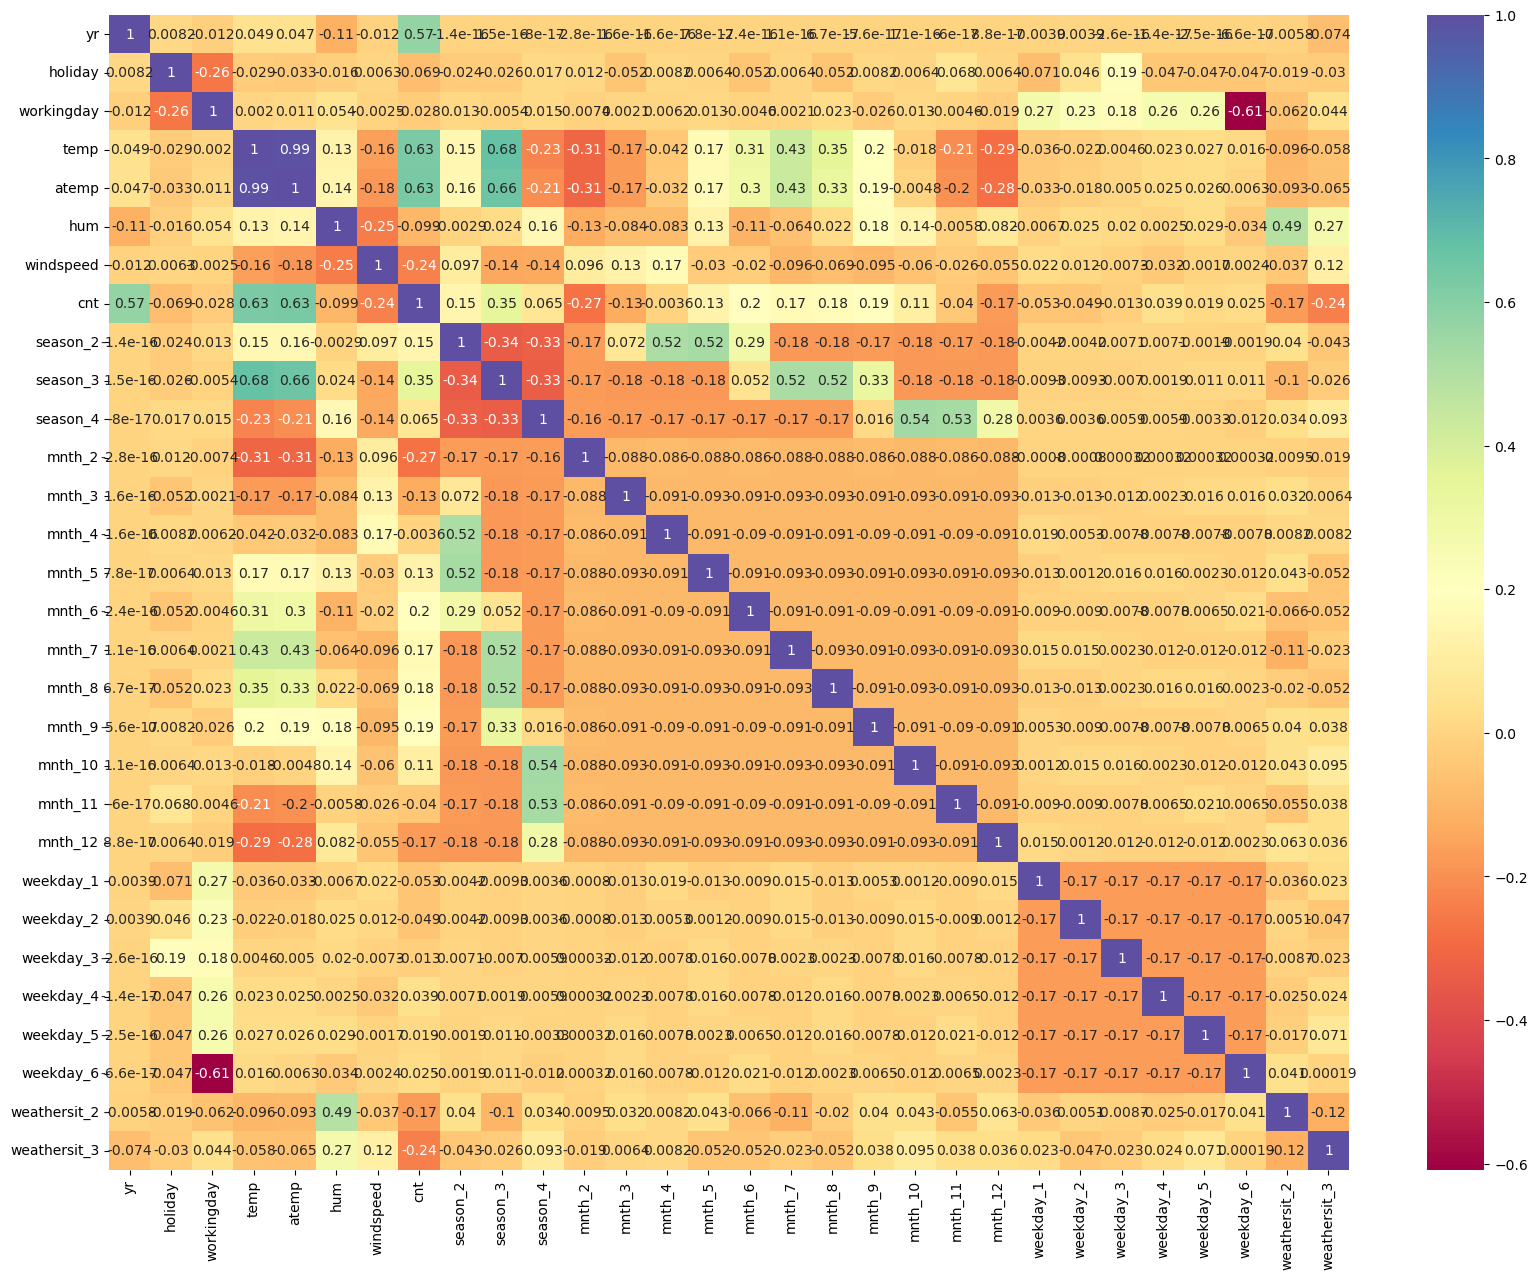

In [46]:
plt.figure(figsize = (20,15))
sns.heatmap(new_bike.corr(), annot = True, cmap = "Spectral")
plt.show()

In the above heatmap, it shows clearly that there is high correlation between the variables, which is multicollinear in nature.
It can be useful for identifying the correct variable and to eliminate from the model.

### Scaling

In [49]:
# Initializing the scaler
scaler = MinMaxScaler()     

In [50]:
train_data.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_2,season_3,...,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_2,weathersit_3
337,0,0,1,13.564153,17.45500,77.5833,5.625206,3485,0,0,...,0,1,0,1,0,0,0,0,0,0
547,1,0,1,32.048347,35.10190,44.7083,13.082889,6227,0,1,...,0,0,0,1,0,0,0,0,0,0
626,1,0,1,22.652500,27.02020,53.6667,14.416725,7591,0,1,...,0,0,0,0,0,1,0,0,0,0
309,0,0,1,14.281653,18.11790,73.4583,6.167631,3649,0,0,...,1,0,0,1,0,0,0,0,0,0
561,1,0,1,31.296653,36.20625,64.5000,11.000529,6830,0,1,...,0,0,0,1,0,0,0,0,0,0


In [51]:
train_data.columns

Index(['yr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed',
       'cnt', 'season_2', 'season_3', 'season_4', 'mnth_2', 'mnth_3', 'mnth_4',
       'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11',
       'mnth_12', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4',
       'weekday_5', 'weekday_6', 'weathersit_2', 'weathersit_3'],
      dtype='object')

In [52]:
# Applying scaling to the specified numeric columns in train_data

numeric_vars = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']

train_data[numeric_vars] = scaler.fit_transform(train_data[numeric_vars])

In [53]:
# Viewing the first few rows of the scaled data 

train_data.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_2,season_3,...,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_2,weathersit_3
337,0,0,1,0.350567,0.361341,0.799484,0.146877,0.398412,0,0,...,0,1,0,1,0,0,0,0,0,0
547,1,0,1,0.932261,0.833624,0.460712,0.412422,0.713875,0,1,...,0,0,0,1,0,0,0,0,0,0
626,1,0,1,0.636576,0.617334,0.553027,0.459915,0.870801,0,1,...,0,0,0,0,0,1,0,0,0,0
309,0,0,1,0.373147,0.379082,0.756977,0.166191,0.417280,0,0,...,1,0,0,1,0,0,0,0,0,0
561,1,0,1,0.908606,0.863180,0.664663,0.338275,0.783249,0,1,...,0,0,0,1,0,0,0,0,0,0


In [54]:
train_data.describe()

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_2,season_3,...,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_2,weathersit_3
count,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,...,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000
mean,0.490196,0.027451,0.696078,0.559712,0.525171,0.642654,0.411024,0.513308,0.245098,0.262745,...,0.082353,0.092157,0.150980,0.141176,0.152941,0.139216,0.137255,0.147059,0.323529,0.031373
std,0.500395,0.163554,0.460401,0.239185,0.221526,0.147058,0.189497,0.222862,0.430568,0.440557,...,0.275172,0.289531,0.358381,0.348545,0.360284,0.346511,0.344454,0.354512,0.468282,0.174494
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.356482,0.335987,0.525440,0.268535,0.362143,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,0.561848,0.540014,0.641691,0.386730,0.522204,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,0.769634,0.709008,0.744633,0.513333,0.676542,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Feature Selection

In [56]:
# X and y sets for model building 

y_train = train_data.pop('cnt')
X_train = train_data

In [57]:
lm = LinearRegression()
lm.fit(X_train, y_train)

rfe = RFE(estimator = lm, n_features_to_select = 15) #running rfe with output number variable 15
rfe.fit(X_train, y_train)

RFE(estimator=LinearRegression(), n_features_to_select=15)

In [58]:
X_train.columns, rfe.support_, rfe.ranking_

(Index(['yr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed',
        'season_2', 'season_3', 'season_4', 'mnth_2', 'mnth_3', 'mnth_4',
        'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11',
        'mnth_12', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4',
        'weekday_5', 'weekday_6', 'weathersit_2', 'weathersit_3'],
       dtype='object'),
 array([ True,  True,  True,  True, False,  True,  True,  True, False,
         True, False, False, False, False, False, False, False,  True,
        False, False, False,  True,  True,  True,  True,  True, False,
        False,  True]),
 array([ 1,  1,  1,  1,  5,  1,  1,  1,  2,  1, 11,  7, 10,  6,  9, 15,  8,
         1,  3, 13, 12,  1,  1,  1,  1,  1, 14,  4,  1]))

In [59]:
# columns which contain the names of the selected features
cols = X_train.columns[rfe.support_]
cols

Index(['yr', 'holiday', 'workingday', 'temp', 'hum', 'windspeed', 'season_2',
       'season_4', 'mnth_9', 'weekday_1', 'weekday_2', 'weekday_3',
       'weekday_4', 'weekday_5', 'weathersit_3'],
      dtype='object')

In [60]:
# columns which contain the names of the features that were not selected
X_train.columns[~rfe.support_]

Index(['atemp', 'season_3', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6',
       'mnth_7', 'mnth_8', 'mnth_10', 'mnth_11', 'mnth_12', 'weekday_6',
       'weathersit_2'],
      dtype='object')

In [61]:
X_train_rfe = X_train[cols]
X_train_rfe

,yr,holiday,workingday,temp,hum,windspeed,season_2,season_4,mnth_9,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weathersit_3
337,0,0,1,0.350567,0.799484,0.146877,0,1,0,0,1,0,0,0,0
547,1,0,1,0.932261,0.460712,0.412422,0,0,0,0,1,0,0,0,0
626,1,0,1,0.636576,0.553027,0.459915,0,0,1,0,0,0,1,0,0
309,0,0,1,0.373147,0.756977,0.166191,0,1,0,0,1,0,0,0,0
561,1,0,1,0.908606,0.664663,0.338275,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,0,0,1,0.330139,0.673679,0.416904,1,0,0,1,0,0,0,0,0
725,1,0,1,0.251648,0.672821,0.781879,0,0,0,0,0,0,0,1,0
9,0,0,1,0.118320,0.497639,0.479220,0,0,0,0,0,1,0,0,0
714,1,0,1,0.391426,0.864319,0.186917,0,1,0,1,0,0,0,0,0


### Model Building

#### Model 1 :-

In [64]:
# VIF check

# Calculating VIF for each feature
vif = pd.DataFrame({'Features': X_train_rfe.columns, 
                    'VIF': [round(variance_inflation_factor(X_train_rfe.values, i), 2) 
                            for i in range(X_train_rfe.shape[1])]})
vif = vif.sort_values(by = "VIF", ascending = False)
vif 

,Features,VIF
2,workingday,390.23
9,weekday_1,85.31
11,weekday_3,85.06
10,weekday_2,79.01
12,weekday_4,78.79
13,weekday_5,77.70
1,holiday,14.19
4,hum,11.87
3,temp,6.83
5,windspeed,4.33


In [65]:
X_train_lm1 = sm.add_constant(X_train_rfe) # Add a constant
lr1 = sm.OLS(y_train, X_train_lm1).fit()   # Creating a first fitted model
lr1.params

const           0.294102
yr              0.221928
holiday        -0.285503
workingday     -0.237343
temp            0.568635
hum            -0.282758
windspeed      -0.177784
season_2        0.087798
season_4        0.151817
mnth_9          0.115324
weekday_1       0.215497
weekday_2       0.200172
weekday_3       0.216555
weekday_4       0.225679
weekday_5       0.225149
weathersit_3   -0.173973
dtype: float64

In [66]:
lr1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     173.0
Date:                Tue, 04 Mar 2025   Prob (F-statistic):          1.54e-185
Time:                        10:32:58   Log-Likelihood:                 509.91
No. Observations:                 510   AIC:                            -987.8
Df Residuals:                     494   BIC:                            -920.1
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.2941      0.026     11.310      0.000       0.243       0.345
yr               0.2219      0.008     27.359      0.000       0.206       0.238
holiday         -0.2855      0.091     -3.130      0.002      -0.465      -0.106
workingday      -0.2373      0.095     -2.498      0.013      -0.424      -0.051
temp             0.5686      0.018     31.114      0.000       0.533       0.605
hum             -0.2828      0.031     -9.239      0.000      -0.343      -0.223
windspeed       -0.1778      0.023     -7.842      0.000      -0.222      -0.133
season_2         0.0878      0.010      8.636      0.000       0.068       0.108
season_4         0.1518      0.010     14.648      0.000       0.131       0.172
mnth_9           0.1153      0.015      7.707      0.000       0.086       0.145
weekday_1        0.2155      0.095      2.262      0.024       0.028       0.403
weekday_2        0.2002      0.095      2.110      0.035       0.014       0.387
weekday_3        0.2166      0.095      2.291      0.022       0.031       0.402
weekday_4        0.2257      0.095      2.367      0.018       0.038       0.413
weekday_5        0.2251      0.095      2.361      0.019       0.038       0.413
weathersit_3    -0.1740      0.025     -7.050      0.000      -0.222      -0.125
==============================================================================
Omnibus:                       39.851   Durbin-Watson:                   2.006
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               51.683
Skew:                          -0.629   Prob(JB):                     5.99e-12
Kurtosis:                       3.922   Cond. No.                         106.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Model 2 :-

In [68]:
#Removing the variable 'workingday' based on its High p-value & High VIF

X_new_train = X_train_rfe.drop(["workingday"], axis = 1)

In [69]:
# VIF Check

# Calculating VIF for each feature
vif = pd.DataFrame({'Features': X_new_train.columns, 
                    'VIF': [round(variance_inflation_factor(X_new_train.values, i), 2) 
                            for i in range(X_new_train.shape[1])]})
vif = vif.sort_values(by = "VIF", ascending = False)
vif 

,Features,VIF
3,hum,11.87
2,temp,6.83
4,windspeed,4.33
0,yr,1.93
6,season_4,1.62
10,weekday_3,1.60
5,season_2,1.58
9,weekday_2,1.53
8,weekday_1,1.51
11,weekday_4,1.49


In [70]:
X_train_lm2 = sm.add_constant(X_new_train) # Add a constant
lr2 = sm.OLS(y_train, X_train_lm2).fit()   # Creating a first fitted model
lr2.params

const           0.290247
yr              0.222919
holiday        -0.066556
temp            0.568942
hum            -0.279833
windspeed      -0.177105
season_2        0.087727
season_4        0.149863
mnth_9          0.115943
weekday_1      -0.020346
weekday_2      -0.034464
weekday_3      -0.017355
weekday_4      -0.010226
weekday_5      -0.010780
weathersit_3   -0.174085
dtype: float64

In [71]:
lr2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     183.0
Date:                Tue, 04 Mar 2025   Prob (F-statistic):          2.45e-185
Time:                        10:32:58   Log-Likelihood:                 506.71
No. Observations:                 510   AIC:                            -983.4
Df Residuals:                     495   BIC:                            -919.9
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.2902      0.026     11.123      0.000       0.239       0.342
yr               0.2229      0.008     27.370      0.000       0.207       0.239
holiday         -0.0666      0.025     -2.617      0.009      -0.117      -0.017
temp             0.5689      0.018     30.968      0.000       0.533       0.605
hum             -0.2798      0.031     -9.102      0.000      -0.340      -0.219
windspeed       -0.1771      0.023     -7.772      0.000      -0.222      -0.132
season_2         0.0877      0.010      8.584      0.000       0.068       0.108
season_4         0.1499      0.010     14.424      0.000       0.129       0.170
mnth_9           0.1159      0.015      7.708      0.000       0.086       0.145
weekday_1       -0.0203      0.013     -1.575      0.116      -0.046       0.005
weekday_2       -0.0345      0.013     -2.588      0.010      -0.061      -0.008
weekday_3       -0.0174      0.013     -1.323      0.187      -0.043       0.008
weekday_4       -0.0102      0.013     -0.768      0.443      -0.036       0.016
weekday_5       -0.0108      0.013     -0.805      0.421      -0.037       0.016
weathersit_3    -0.1741      0.025     -7.017      0.000      -0.223      -0.125
==============================================================================
Omnibus:                       39.047   Durbin-Watson:                   2.019
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               49.911
Skew:                          -0.626   Prob(JB):                     1.45e-11
Kurtosis:                       3.883   Cond. No.                         15.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Model 3 :-

In [73]:
# Removing the variable 'hum' based on its Very High 'VIF' value.

X_new_train = X_new_train.drop(["hum"], axis = 1)

In [74]:
# VIF Check

# Calculating VIF for each feature
vif = pd.DataFrame({'Features': X_new_train.columns, 
                    'VIF': [round(variance_inflation_factor(X_new_train.values, i), 2) 
                            for i in range(X_new_train.shape[1])]})
vif = vif.sort_values(by = "VIF", ascending = False)
vif 

,Features,VIF
2,temp,4.41
3,windspeed,3.67
0,yr,1.92
4,season_2,1.55
9,weekday_3,1.49
7,weekday_1,1.44
8,weekday_2,1.43
11,weekday_5,1.42
10,weekday_4,1.40
5,season_4,1.38


In [75]:
X_train_lm3 = sm.add_constant(X_new_train) # Add a constant
lr3 = sm.OLS(y_train, X_train_lm3).fit()   # Creating a first fitted model
lr3.params

const           0.117092
yr              0.229779
holiday        -0.071897
temp            0.545970
windspeed      -0.133932
season_2        0.079572
season_4        0.134217
mnth_9          0.097523
weekday_1      -0.024504
weekday_2      -0.045840
weekday_3      -0.026688
weekday_4      -0.016653
weekday_5      -0.015537
weathersit_3   -0.240572
dtype: float64

In [76]:
lr3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     163.7
Date:                Tue, 04 Mar 2025   Prob (F-statistic):          6.63e-170
Time:                        10:32:58   Log-Likelihood:                 467.25
No. Observations:                 510   AIC:                            -906.5
Df Residuals:                     496   BIC:                            -847.2
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1171      0.019      6.073      0.000       0.079       0.155
yr               0.2298      0.009     26.251      0.000       0.213       0.247
holiday         -0.0719      0.027     -2.620      0.009      -0.126      -0.018
temp             0.5460      0.020     27.796      0.000       0.507       0.585
windspeed       -0.1339      0.024     -5.567      0.000      -0.181      -0.087
season_2         0.0796      0.011      7.241      0.000       0.058       0.101
season_4         0.1342      0.011     12.136      0.000       0.112       0.156
mnth_9           0.0975      0.016      6.062      0.000       0.066       0.129
weekday_1       -0.0245      0.014     -1.759      0.079      -0.052       0.003
weekday_2       -0.0458      0.014     -3.204      0.001      -0.074      -0.018
weekday_3       -0.0267      0.014     -1.890      0.059      -0.054       0.001
weekday_4       -0.0167      0.014     -1.161      0.246      -0.045       0.012
weekday_5       -0.0155      0.014     -1.076      0.283      -0.044       0.013
weathersit_3    -0.2406      0.026     -9.401      0.000      -0.291      -0.190
==============================================================================
Omnibus:                       39.477   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               48.381
Skew:                          -0.658   Prob(JB):                     3.12e-11
Kurtosis:                       3.737   Cond. No.                         10.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

No action required for VIF since they are all below the threshold of 10.
Considering by removing variables with high p-values (such as weekday_1, weekday_4, and weekday_5) if they are not contributing significantly to the model's predictive power.

#### Model 4 :-

In [79]:
# Removing the variables as high with p-values that are no significance

X_new_train = X_new_train.drop(["weekday_1", "weekday_3", "weekday_4", "weekday_5"], axis=1)

In [80]:
# VIF Check

# Calculating VIF for each feature
vif = pd.DataFrame({'Features': X_new_train.columns, 
                    'VIF': [round(variance_inflation_factor(X_new_train.values, i), 2) 
                            for i in range(X_new_train.shape[1])]})
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
2,temp,3.74
3,windspeed,3.42
0,yr,1.91
4,season_2,1.54
5,season_4,1.35
6,mnth_9,1.20
7,weekday_2,1.17
8,weathersit_3,1.08
1,holiday,1.04


In [81]:
X_train_lm4 = sm.add_constant(X_new_train) # Add a constant
lr4 = sm.OLS(y_train, X_train_lm4).fit()   # Creating a first fitted model
lr4.params

const           0.101792
yr              0.230730
holiday        -0.078166
temp            0.545086
windspeed      -0.131129
season_2        0.079795
season_4        0.134552
mnth_9          0.098120
weekday_2      -0.031470
weathersit_3   -0.243825
dtype: float64

In [82]:
lr4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     235.4
Date:                Tue, 04 Mar 2025   Prob (F-statistic):          1.77e-173
Time:                        10:32:58   Log-Likelihood:                 464.67
No. Observations:                 510   AIC:                            -909.3
Df Residuals:                     500   BIC:                            -867.0
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1018      0.018      5.700      0.000       0.067       0.137
yr               0.2307      0.009     26.384      0.000       0.214       0.248
holiday         -0.0782      0.027     -2.915      0.004      -0.131      -0.025
temp             0.5451      0.020     27.750      0.000       0.506       0.584
windspeed       -0.1311      0.024     -5.458      0.000      -0.178      -0.084
season_2         0.0798      0.011      7.274      0.000       0.058       0.101
season_4         0.1346      0.011     12.174      0.000       0.113       0.156
mnth_9           0.0981      0.016      6.104      0.000       0.067       0.130
weekday_2       -0.0315      0.013     -2.498      0.013      -0.056      -0.007
weathersit_3    -0.2438      0.025     -9.572      0.000      -0.294      -0.194
==============================================================================
Omnibus:                       34.595   Durbin-Watson:                   1.986
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               41.415
Skew:                          -0.607   Prob(JB):                     1.02e-09
Kurtosis:                       3.691   Cond. No.                         9.53
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The model seems reliable, as there is very little multicollinearity among the predictors, and all the predictors have statistically significant p-values. Proceeding with this as the final model, unless the performance on the test data reveals substantial deviations from these metrics.

#### Hypothesis Testing

From the lr4 model summary, it is evident that all our coefficients are not equal to zero which means We REJECT the NULL HYPOTHESIS

F-statistic: 235.4
Prob (F-statistic): 1.77e-173
The F-Statistics value of 235.4 (which is greater than 1) and the p-values states that the overall model is significant

### Assumption

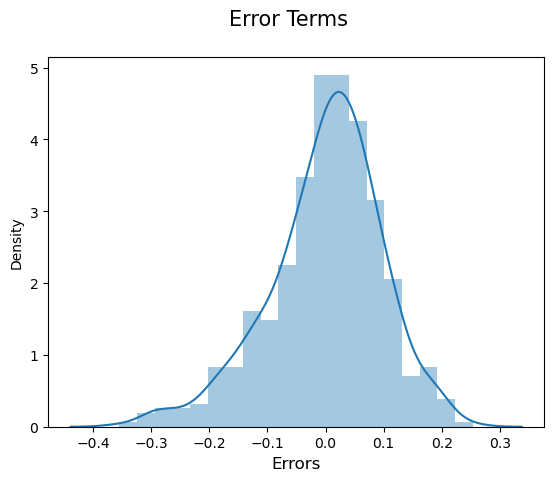

In [88]:
y_train_pred = lr4.predict(X_train_lm4)   # Residual analysis
res = y_train-y_train_pred

fig = plt.figure()
sns.distplot((res), bins = 20)
plt.xlabel('Errors', fontsize = 12)
fig.suptitle('Error Terms', fontsize = 15)
plt.show()

Residuals are normally distributed, Hence the assumption for Linear Regression is valid.

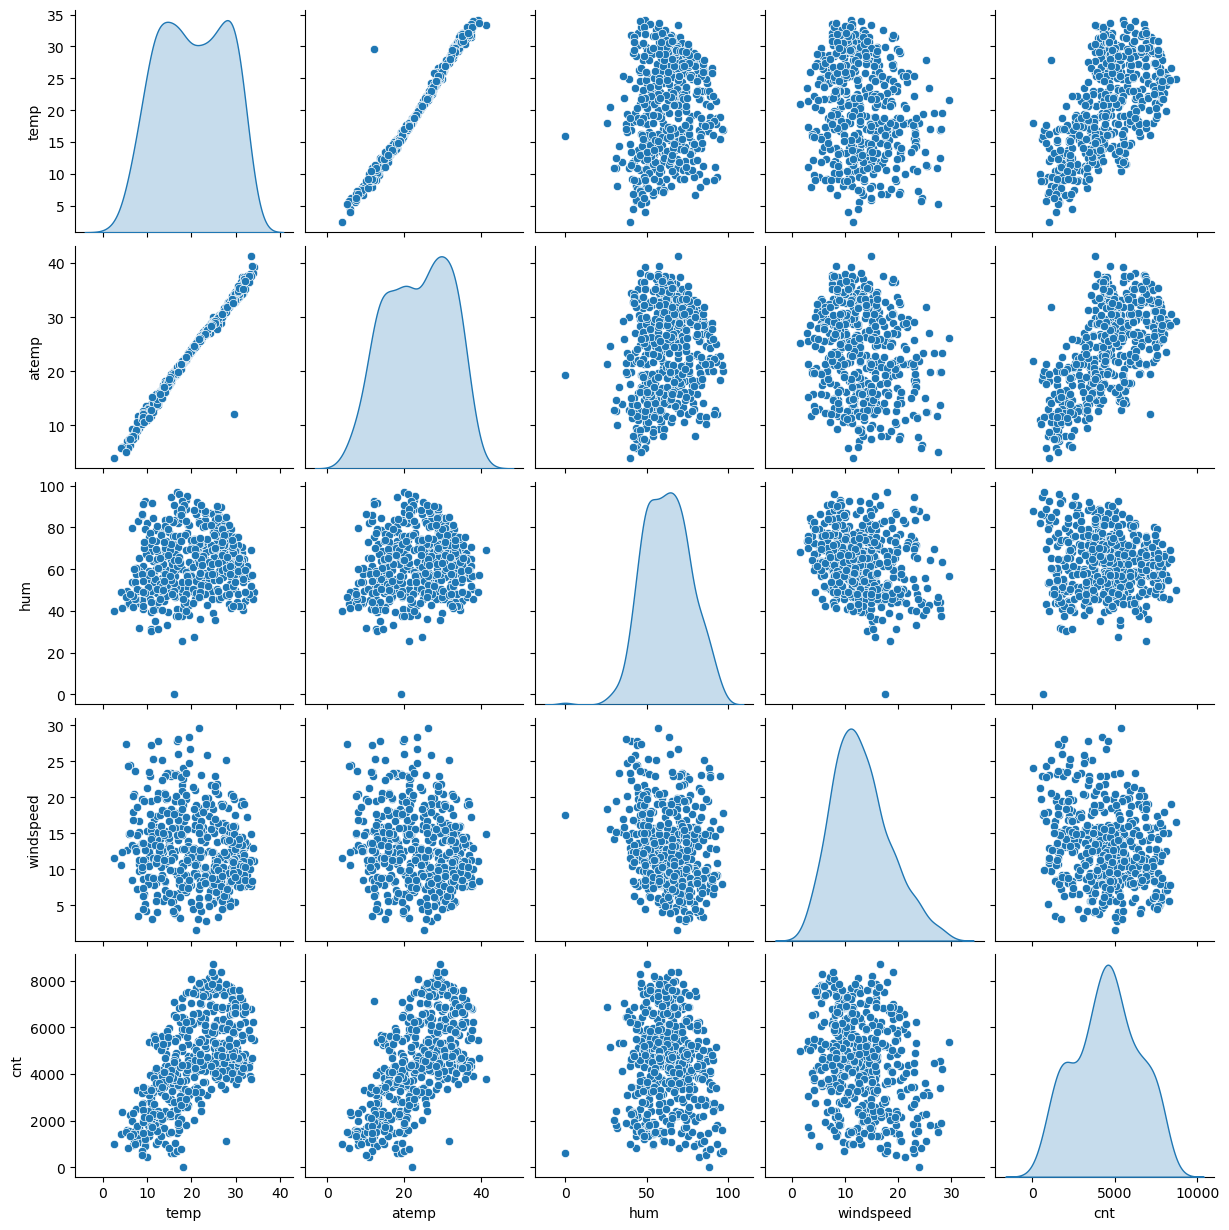

In [90]:
new_bike = new_bike[[ 'temp', 'atemp', 'hum', 'windspeed','cnt']]

sns.pairplot(num_cols_in_bike, diag_kind='kde')
plt.show()

By seeing above pair plot it shows the linear relation between temp and atemp variable with the predictor ‘cnt’.

In [92]:
# Checking for multicollinearity

vif = pd.DataFrame({'Features': X_new_train.columns, 
                    'VIF': [round(variance_inflation_factor(X_new_train.values, i), 2) 
                            for i in range(X_new_train.shape[1])]})
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
2,temp,3.74
3,windspeed,3.42
0,yr,1.91
4,season_2,1.54
5,season_4,1.35
6,mnth_9,1.20
7,weekday_2,1.17
8,weathersit_3,1.08
1,holiday,1.04


Based on the VIF calculation, we can conclude that there is no multicollinearity among the predictor variables, as all the VIF values fall within the acceptable range of below 5.

### Prediction of final model

In [95]:
numeric_var = ['temp', 'atemp', 'hum', 'windspeed','cnt']

test_data[numeric_var] = scaler.transform(test_data[numeric_var])
test_data.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_2,season_3,...,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_2,weathersit_3
146,0,0,0,0.803235,0.746604,0.673679,0.520759,0.535780,1,0,...,0,0,0,0,0,0,0,0,0,0
263,0,0,1,0.691412,0.630888,0.927436,0.176569,0.498159,0,1,...,0,0,0,0,0,0,1,0,1,0
426,1,0,0,0.458090,0.447507,0.640189,0.330861,0.465255,0,0,...,0,0,0,0,0,0,0,0,1,0
552,1,0,0,1.035482,0.971286,0.507084,0.336765,0.554303,0,1,...,0,0,0,0,0,0,0,0,0,0
302,0,0,1,0.335515,0.324179,0.642765,0.367929,0.380695,0,0,...,0,0,0,1,0,0,0,0,0,0


In [96]:
test_data.describe()

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_2,season_3,...,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_2,weathersit_3
count,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,...,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000
mean,0.525114,0.031963,0.680365,0.569135,0.536613,0.656808,0.378012,0.522974,0.269406,0.242009,...,0.082192,0.068493,0.127854,0.150685,0.118721,0.150685,0.155251,0.132420,0.369863,0.022831
std,0.500513,0.176306,0.467403,0.228218,0.208893,0.145989,0.172753,0.223252,0.444668,0.429281,...,0.275286,0.253169,0.334692,0.358561,0.324202,0.358561,0.362974,0.339723,0.483873,0.149707
min,0.000000,0.000000,0.000000,0.048245,0.026455,0.193646,0.057872,0.047055,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.363471,0.349520,0.554315,0.266299,0.361194,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,0.595717,0.573409,0.661228,0.357540,0.520709,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,0.766677,0.707754,0.758909,0.484403,0.709388,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.035482,1.019437,1.002146,1.157215,0.981707,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [97]:
# X and y sets for model building 

y_test = test_data.pop('cnt')
X_test = test_data
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 219 entries, 146 to 293
Data columns (total 29 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   yr            219 non-null    int64  
 1   holiday       219 non-null    int64  
 2   workingday    219 non-null    int64  
 3   temp          219 non-null    float64
 4   atemp         219 non-null    float64
 5   hum           219 non-null    float64
 6   windspeed     219 non-null    float64
 7   season_2      219 non-null    uint8  
 8   season_3      219 non-null    uint8  
 9   season_4      219 non-null    uint8  
 10  mnth_2        219 non-null    uint8  
 11  mnth_3        219 non-null    uint8  
 12  mnth_4        219 non-null    uint8  
 13  mnth_5        219 non-null    uint8  
 14  mnth_6        219 non-null    uint8  
 15  mnth_7        219 non-null    uint8  
 16  mnth_8        219 non-null    uint8  
 17  mnth_9        219 non-null    uint8  
 18  mnth_10       219 non-null    uin

In [98]:
# Selecting the columns used in the final model
selected_cols = X_new_train.columns
selected_X_test = X_test[selected_cols]

X_test_lm4 = sm.add_constant(selected_X_test)     # Add a constant
X_test_lm4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 219 entries, 146 to 293
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   const         219 non-null    float64
 1   yr            219 non-null    int64  
 2   holiday       219 non-null    int64  
 3   temp          219 non-null    float64
 4   windspeed     219 non-null    float64
 5   season_2      219 non-null    uint8  
 6   season_4      219 non-null    uint8  
 7   mnth_9        219 non-null    uint8  
 8   weekday_2     219 non-null    uint8  
 9   weathersit_3  219 non-null    uint8  
dtypes: float64(3), int64(2), uint8(5)
memory usage: 11.3 KB


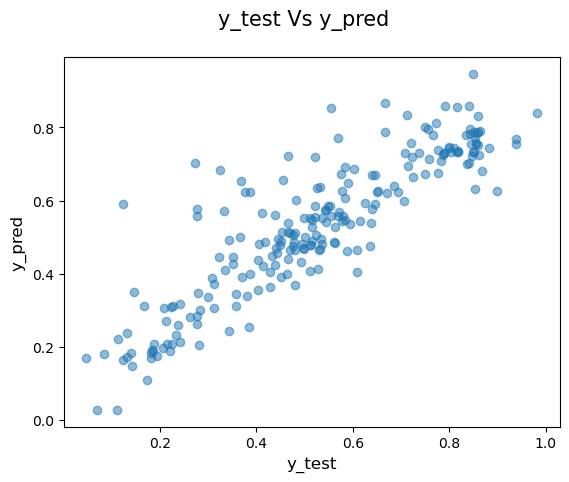

In [99]:
y_pred = lr4.predict(X_test_lm4)
fig = plt.figure()
plt.scatter(y_test, y_pred, alpha = 0.5)
plt.xlabel('y_test', fontsize = 12)                 
plt.ylabel('y_pred', fontsize = 12) 
fig.suptitle('y_test Vs y_pred', fontsize = 15)
plt.show()

### R-Squared Test

In [101]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.7672936218396058

### Adjusted R-Squared Test

In [103]:
r2 = 0.7672936218396058

In [104]:
X_test.shape

(219, 29)

In [105]:
n = X_test.shape[0]
p = X_test.shape[1]

# Adjusted R-squared using the formula

adjusted_r2_test = 1-(1-r2)*(n-1)/(n-p-1)
adjusted_r2_test

0.7315873521747834

##### Comparison between result of test data and train data

1. Train R-squared :0.809
2. Train Adjusted R-squared :0.806
3. Test R-squared :0.767
4. Test Adjusted R-squared :0.731

It seems that the model demonstrates strong generalization, performing well on both training and test datasets.

##### Summary Report:

1. Constant (0.101792): Baseline value of the dependent variable when all predictors are zero.
2. Year (0.230730): Positive impact on demand, indicating increased demand over the years.
3. Holiday (-0.078166): Slight decrease in demand during holidays.
4. Temperature (0.545086): Strong positive relationship, higher temperatures lead to increased demand.
5. Windspeed (-0.131129): Negative impact, higher wind speeds decrease demand.
6. Season_2 (0.079795) & Season_4 (0.134552): Both seasons show slight positive effects on demand.
7. Month_9 (0.098120): Positive effect, indicating increased demand in September.
8. Weekday_2 (-0.031470): Small negative impact on demand on Tuesdays.
9. Weather Situation 3 (-0.243825): Strong negative impact, poor weather significantly reduces demand.

##### Key Insights:

1. Temperature is the strongest positive factor for bike demand.
2. Weather conditions and windspeed negatively impact demand.
3. Year, seasons, and month positively influence demand.
4. Holidays and specific weekdays like Tuesday slightly reduce demand.

##### Conclusion:

Demand for shared bikes is mainly driven by temperature, season, and year, while weather conditions, wind, holidays, and weekdays can reduce demand.